Measure how often recalls move from a newly revisited repeated item to the neighbours of its earlier presentation. The `min_lag` filter enforces spaced repetitions, and the resulting curve highlights backward spread relative to the full forward/backward profile charted in `repcrp`.

Adjust `control_trial_query` to define alternative control populations.

Modify `min_lag` if you need to tighten or relax the spacing filter.


In [1]:
# import jax
# jax.config.update("jax_disable_jit", True)
# jax.config.update("jax_debug_nans", True)

import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.cleanbackrepcrp import (
    plot_back_rep_crp,
    subject_back_rep_crp,
    test_back_rep_crp_vs_control,
    test_first_second_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/LohnasKahana2014_FullPositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "LohnasKahana2014_FullPositionalCMRNoStop_rerun_best_of_1_backrepcrp.png"
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
ylim = [0.05, 0.32]


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


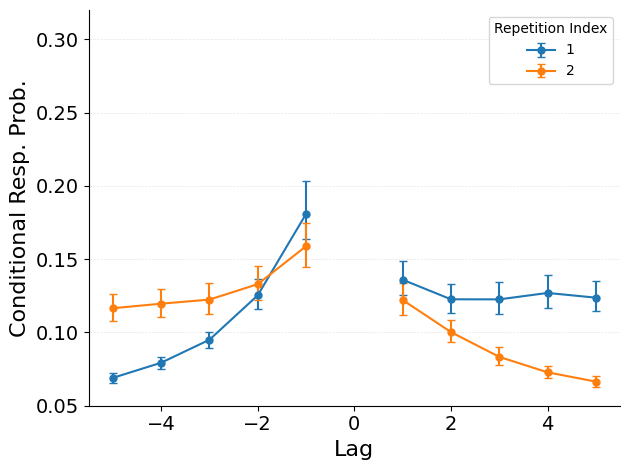

/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/stats/_resampling.py:141: RuntimeWarning: invalid value encountered in subtract
  U_ji = [(n - 1) * (theta_hat_dot - theta_hat_i)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:194: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


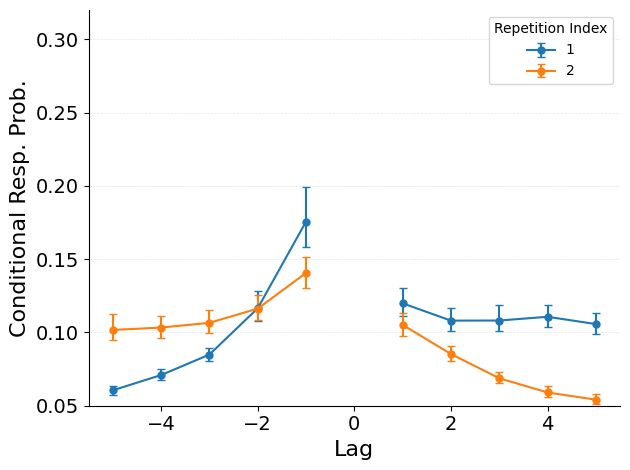

In [5]:
plot_back_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")
plot_back_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")


In [6]:
observed_crp = subject_back_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_back_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_back_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    5.981     0.0000 |     42.0     0.0000 |     0.0085
   -4 |    5.886     0.0000 |     44.0     0.0000 |     0.0084
   -3 |    7.261     0.0000 |      4.0     0.0000 |     0.0101
   -2 |    4.166     0.0002 |     89.0     0.0001 |     0.0088
   -1 |    1.874     0.0695 |    163.0     0.0118 |     0.0052
    0 |      nan        nan |      nan        nan |        nan
    1 |    8.704     0.0000 |      7.0     0.0000 |     0.0161
    2 |    8.775     0.0000 |      6.0     0.0000 |     0.0146
    3 |    7.134     0.0000 |     18.0     0.0000 |     0.0144
    4 |    6.250     0.0000 |     48.0     0.0000 |     0.0163
    5 |    8.438     0.0000 |      8.0     0.0000 |     0.0180

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:476: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:487: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)


In [7]:
bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print("H0: The preference for first-presentation neighbors over second-presentation")
print("    neighbors is the same in observed data as in the shuffled control.")
print()
print(bias_result)


Test: First-Second Bias (Observed) vs First-Second Bias (Control)
H0: The preference for first-presentation neighbors over second-presentation
    neighbors is the same in observed data as in the shuffled control.

  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |   -2.964     0.0055 |    150.0     0.0060 |    -0.0063
   -4 |   -3.889     0.0004 |     97.0     0.0002 |    -0.0079
   -3 |   -3.519     0.0013 |    116.0     0.0007 |    -0.0057
   -2 |   -2.676     0.0114 |    171.0     0.0174 |    -0.0078
   -1 |   -4.149     0.0002 |     65.0     0.0000 |    -0.0130
    0 |      nan        nan |      nan        nan |        nan
    1 |   -0.518     0.6079 |    275.0     0.5223 |    -0.0009
    2 |   -0.219     0.8280 |    302.0     0.8398 |    -0.0004
    3 |   -0.082     0.9350 |    299.0     0.8020 |    -0.0002
    4 |    1.320     0.1956 |    178.0     0.0241 |     0.0025
    5 |    3.317     0.00

/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:531: RuntimeWarning: invalid value encountered in subtract
  control_diff = control_crp[:, 0, :] - control_crp[:, 1, :]
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:545: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/jaxcmr/jaxcmr/analyses/backrepcrp.py:556: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff_of_diff)
